# Prior-Data Fitted Networks (part 2)
Now we know how to train a simple PFN for a simple regression tasks. 
In this part we want to focus on getting better priors.

In [1]:
# basic imports
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
from torch.nn.modules.transformer import MultiheadAttention

if torch.cuda.is_available():
    device = torch.device("cuda")
    print("Using GPU:", device)
else:
    device = torch.device("cpu")
    print("No GPU -> using CPU:", device)

No GPU -> using CPU: cpu


## Transformer model

We start with Transfomer architecture for our PFN. The model predicts probability mass function.

In [3]:
class PriorDataLoader(object):
    def __init__(self, get_prior_data_fn, batch_size, num_points_in_each_dataset, seed=0):
        self.batch_size = batch_size
        self.num_points_in_each_dataset = num_points_in_each_dataset
        self.get_prior_data_fn = get_prior_data_fn
        self.epoch = 0
        self.rng = np.random.default_rng(seed)  

        min_samples = 1
        max_samples = self.num_points_in_each_dataset - 1
        self._trainset_sizes = np.arange(min_samples, max_samples)
        self._trainset_weights = 1 / (max_samples - min_samples - np.arange(max_samples - min_samples))
        self._trainset_weights /= self._trainset_weights.sum()  # normalize

    def get_batch(self, train = True, batch_size=None):
        """
        Returns:
            xs, ys, trainset_size
        """
        self.epoch += train
        bs = batch_size if batch_size else self.batch_size
        return self.get_prior_data_fn(bs, self.num_points_in_each_dataset), self._sample_trainset_size()

    def _sample_trainset_size(self):
        # weighted sampling using NumPy RNG
        return self.rng.choice(self._trainset_sizes, p=self._trainset_weights)


class BarDistribution(nn.Module):
    def __init__(self, bucket_limits: torch.Tensor = None):
        super().__init__()

        self.bucket_limits = bucket_limits
        if bucket_limits is not None:
            self.bucket_widths = self.bucket_limits[1:] - self.bucket_limits[:-1]
            self.bucket_means = self.bucket_limits[:-1] + self.bucket_widths / 2

    def set_buckets(self, num_outputs, ys):
        self.bucket_limits = self.get_bucket_limits(num_outputs, ys)
        self.bucket_widths = self.bucket_limits[1:] - self.bucket_limits[:-1]
        self.bucket_means = self.bucket_limits[:-1] + self.bucket_widths / 2

    def get_bucket_limits(self, num_outputs, ys):
        """
        Create bucket borders for y by sorting and splitting into equal parts.
        """
        ys = ys.flatten()
        n = len(ys) - len(ys) % num_outputs
        ys_sorted, _ = ys[:n].sort()
        step = n // num_outputs
        mids = (ys_sorted[step-1::step][:-1] + ys_sorted[step::step]) / 2
        return torch.cat([ys_sorted[:1], mids, ys_sorted[-1:]])


    def y_to_bucket_idx(self, ys):
        """
        Maps the value of y to the corresponding bucket in `bucket_limits`
        """
        target_sample = torch.searchsorted(self.bucket_limits, ys) - 1
        target_sample[ys <= self.bucket_limits[0]] = 0
        target_sample[ys >= self.bucket_limits[-1]] = len(self.bucket_limits) - 1 - 1
        return target_sample
        
    def mean(self, logits):
        p = torch.softmax(logits, dim=-1)
        
        side_normals = (
            self.get_halfnormal_with_p_weight_before(self.bucket_widths[0]),
            self.get_halfnormal_with_p_weight_before(self.bucket_widths[-1])
        )
        self.bucket_means[0] = -side_normals[0].mean + self.bucket_widths[1]
        self.bucket_means[-1] = side_normals[1].mean + self.bucket_widths[-2]

        return p @ self.bucket_means

    def cdf(self, logits, left_prob):
        """
        Computes quantile corresponding to left_prob
        """
        probs = torch.softmax(logits, -1)
        cumprobs = torch.cumsum(probs, -1)
        idx = torch.searchsorted(cumprobs, left_prob * torch.ones(*cumprobs.shape[:-1], 1)).squeeze(-1).clamp(0, cumprobs.shape[-1] - 1)
        cumprobs = torch.cat([torch.zeros(*cumprobs.shape[:-1], 1, device=logits.device), cumprobs], -1)
        
        rest_prob = left_prob - cumprobs.gather(-1, idx[..., None]).squeeze(-1)
        left_border = bucket_limits[idx]
        right_border = bucket_limits[idx+1]
        return left_border + (right_border - left_border) * rest_prob / probs.gather(-1, idx[..., None]).squeeze(-1)

    def compute_quantile(logits, bucket_limits, center_prob = 0.682):
        """
        Computes +/- quantiles corresponding to cetner_prob.
        """
        side_prob = (1.0-center_prob)/2 # center_prob = 0.682 area under the normal function within 1 std
        return torch.stack([self.cdf(logits, side_prob), self.cdf(logits, 1-side_prob)], -1)

    def get_halfnormal_with_p_weight_before(self, range_max, p=0.5):
        """Half-normal scaled so that `p` portion lies within range_max."""
        s = range_max / torch.distributions.HalfNormal(1.).icdf(torch.tensor(p))
        return torch.distributions.HalfNormal(s)

    def forward(self,   logits: torch.Tensor, target_y: torch.Tensor,):
        target_idx =  self.y_to_bucket_idx(target_y)
        widths = self.bucket_limits[1:] - self.bucket_limits[:-1]
        log_probs = torch.log_softmax(logits, -1) - torch.log(widths)
        log_probs = log_probs.gather(-1, target_idx[..., None]).squeeze(-1)

        # Half-normal edge corrections
        left, right = self.get_halfnormal_with_p_weight_before(widths[0]), self.get_halfnormal_with_p_weight_before(widths[-1])
        first, last = target_idx == 0, target_idx == len(widths)-1
        
        if first.any():
            log_probs[first] += (left.log_prob(self.bucket_limits[1]-target_y[first])
                                .clamp(min=1e-8) + torch.log(widths[0]))
        if last.any():
            log_probs[last] += (right.log_prob(target_y[last]-self.bucket_limits[-2])
                                .clamp(min=1e-8) + torch.log(widths[-1]))
        return -log_probs.mean()


class Encoder(nn.Module):
    """Typical self attention module in transformer"""
    def __init__(self, d_model, n_heads, n_hidden, dropout=0.1):
        super().__init__()
        self.self_attn = MultiheadAttention(d_model, n_heads, dropout=dropout, batch_first=True)
        self.out = nn.Sequential(
            nn.Linear(d_model, n_hidden),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(n_hidden, d_model),
        )
        
        self.dropout = nn.Dropout(dropout)
        self.norm1 = nn.LayerNorm(d_model)
        self.norm2 = nn.LayerNorm(d_model)
        
    def forward(self, src, trainset_size):
        src_left, src_right = src[:, :trainset_size], src[:, trainset_size:]
        x_left = self.self_attn(src_left, src_left, src_left)[0] # all train points to each other
        x_right = self.self_attn(src_right, src_left, src_left)[0] # test points attend to train points
        x = torch.cat([x_left, x_right], dim=1)
        x = self.norm1(src + self.dropout(x))
        return self.norm2(self.dropout(self.out(x)) + x)


class Transformer(nn.Module):
    def __init__(self, num_features, n_out , criterion, n_layers=2, d_model=512, n_heads=4, n_hidden=1024, dropout=0.0, normalize=lambda x:x):
        super().__init__()
        self.criterion = criterion
        self.x_encoder = nn.Linear(num_features, d_model)
        self.y_encoder = nn.Linear(1, d_model)
        
        self.model = nn.ModuleList(
            [Encoder(d_model, n_heads, n_hidden, dropout) for _ in range(n_layers)]
        )
        
        self.out = nn.Sequential(
            nn.Linear(d_model, n_hidden),
            nn.GELU(),
            nn.Linear(n_hidden, n_out)
        )
                
        self.normalize = normalize
        self.init_weights()
        
    def forward(self, x, y, trainset_size):
        """
        Args:
            x: num_datasets x number_of_points x num_features
            y: num_datasets x number_of_points
            trainset_size: int specifying the number of points to use as training dataset size
        
        Returns:
            outputs for each x
        """
        x_src = self.x_encoder(self.normalize(x))
        y_src = self.y_encoder(y)
        
        src = torch.cat([x_src[:, :trainset_size] + y_src[:, :trainset_size], x_src[:, trainset_size:]], dim=1)
        for encoder in self.model:
            src = encoder(src, trainset_size)

        return self.out(src)
    
    def init_weights(self):
        for p in self.parameters():
            if p.dim() > 1:
                nn.init.xavier_uniform_(p)

In [4]:
def train_model(model, optimizer, scheduler, dl, epochs=10, steps_per_epoch=100, validate_epoch=10):
    model.to(device)
    (test_xs, test_ys), test_trainset_size = dl.get_batch(False, 64)
    test_xs, test_ys = test_xs.to(device), test_ys.to(device)

    for step in range(epochs * steps_per_epoch + 1):
        (xs, ys), trainset_size = dl.get_batch()
        xs, ys = xs.to(device), ys.to(device)
        pred_y = model(xs, ys.unsqueeze(-1), trainset_size)
        
        logits = pred_y[:, trainset_size:]
        target_y = ys[:, trainset_size:].clone().view(*logits.shape[:-1])
        
        loss = model.criterion(logits, target_y)
        
        optimizer.zero_grad()
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.)
        optimizer.step()
        scheduler.step()
        
        if step % (validate_epoch * steps_per_epoch) == 0:
            with torch.no_grad():
                pred_test_y = model(test_xs, test_ys.unsqueeze(-1), test_trainset_size)
                logits = pred_test_y[:, test_trainset_size:]
                target_test_y = test_ys[:, test_trainset_size:].clone().view(*logits.shape[:-1])
                val_loss = model.criterion(logits, target_test_y)
                print(f'@Step: {step}\tVal loss:{val_loss.item(): 0.5f}\t lr:{scheduler.get_last_lr()[0]: 0.6e}\t train_loss:{loss.item(): 0.5f}')

## Data Generating Prior

For a Prior-Data Fitted Network (PFN), it's crucial to generate synthetic data based on well-defined priors. In this tutorial, we'll explore a PFN designed to approximate the Posterior Predictive Distribution (PPD), where the model parameters $\theta$ are drawn from a normal distribution centered around the origin.

---

### Logistic Regression Model
We start with the simplest prior. We want to predict PPD for normally distributed outcomes. Each dataset has $X$ (n × p features) and $y$ (n targets) with unknown $\beta$ (p coefficients).

We model the output (likelihood) as:

$$
y = X \beta + \epsilon, \quad \epsilon \sim N(0, \sigma^2 I)
$$

Where  $\sigma^2$ is the likelihood variance (noise in y). The coefficients $\beta$ are sampled from a normal distribution (Gaussian / Ridge-like):  

$$
\beta \sim N(0, \tau^2 I)
$$

Where $\tau^2$ is the prior variance.

Refrereces:

https://en.wikipedia.org/wiki/Bayesian_linear_regression

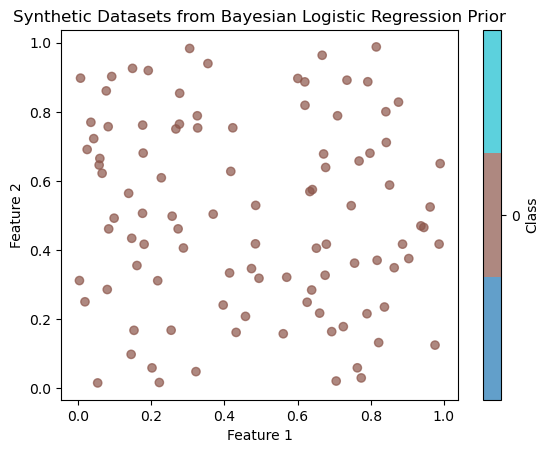

In [363]:
num_datasets = 1
num_classes = 3
num_points_in_each_dataset = 100
hyperparameters = {
    'prior_variance': 0.1,
}
num_features = 2
temperature = 0.01

def generate_bayesian_logistic_regression_prior(
    num_datasets, num_features, num_points_in_each_dataset, num_classes, hyperparameters
):
    # Sample weights per dataset and per class (with bias term)
    beta_s = torch.distributions.Normal(
        torch.zeros(num_classes, num_features + 1),
        hyperparameters['prior_variance']
    ).sample((num_datasets,))  # shape: (num_datasets, num_classes, num_features+1)

    # Sample inputs
    Xs = torch.rand(num_datasets, num_points_in_each_dataset, num_features).float() 
    Xs_ = torch.cat([Xs, torch.ones(num_datasets, num_points_in_each_dataset, 1)], dim=-1)  # add bias

    # Compute logits: (num_datasets, num_points, num_classes)
    logits = torch.einsum('ndf,ncf->ndc', Xs_, beta_s)

    if num_classes == 2:
        logits = logits[..., 1] - logits[..., 0]  # shape: (num_datasets, num_points)
        probs = torch.sigmoid(logits/temperature)
        ys = torch.bernoulli(probs)
    else:
        ys = torch.distributions.Categorical(logits=logits/temperature).sample().float()  # Multi-class logistic regression → softmax
    return Xs, ys

Xs, ys = generate_bayesian_logistic_regression_prior(num_datasets, num_features, num_points_in_each_dataset, num_classes, hyperparameters)


for dataset_index in range(num_datasets):
    plt.scatter(Xs[dataset_index,:,0].numpy(), Xs[dataset_index,:,1].numpy(), c=ys[dataset_index].numpy(), cmap=plt.get_cmap('tab10', num_classes), alpha=0.7)
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.title('Synthetic Datasets from Bayesian Logistic Regression Prior')
plt.colorbar(ticks=range(num_classes), label='Class')
plt.show()

In [365]:
from transformers import get_cosine_schedule_with_warmup
# Parameters related to prior data
num_points_in_each_dataset = 32
hyperparameters = {
    'prior_variance': 0.1,
}
num_features = 2
num_classes = 3
num_outputs = num_classes
max_num_datasets = 128

_, ys = generate_bayesian_logistic_regression_prior(100000, num_features, num_outputs, num_classes, hyperparameters)
criterion = BarDistribution()
criterion.set_buckets(num_outputs, ys)


# training data
get_prior_data_fn = lambda x, y: generate_bayesian_logistic_regression_prior(x, num_features, y, num_classes, hyperparameters)
dl = PriorDataLoader(get_prior_data_fn, batch_size=max_num_datasets, num_points_in_each_dataset=num_points_in_each_dataset)
# Models
model = Transformer(criterion=criterion, num_features=num_features, n_out=num_outputs, d_model=16, n_layers=4, n_hidden=32, n_heads=4)

# Learning
epochs = 20
steps_per_epoch = 100
warmup_epochs = epochs // 4
validate_epoch = 5
lr = 0.001
optimizer = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=1e-4)
scheduler = get_cosine_schedule_with_warmup(optimizer, warmup_epochs * steps_per_epoch, epochs * steps_per_epoch)
train_model(model, optimizer, scheduler, dl, epochs, steps_per_epoch, validate_epoch)



ValueError: Expected parameter scale (Tensor of shape ()) of distribution HalfNormal() to satisfy the constraint GreaterThan(lower_bound=0.0), but found invalid values:
0.0

## Compute metrics and visualize

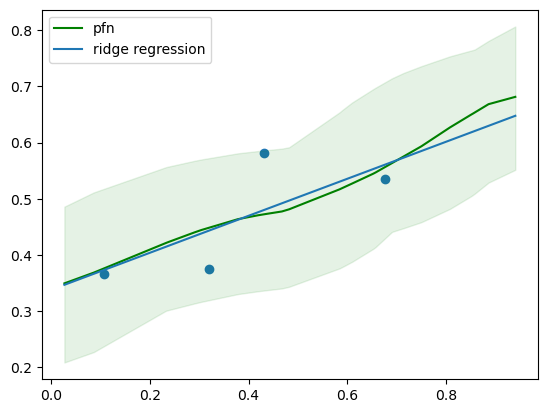

In [174]:
import sklearn

(xs, ys), num_training_points = dl.get_batch()

batch_index = 0
num_training_points = 4 # this is the trainset_size

xs_train = xs[batch_index, :num_training_points]
ys_train = ys[batch_index, :num_training_points]
xs_test = xs[batch_index, num_training_points:]

with torch.no_grad():
    logits = model(xs.to(device), ys.unsqueeze(-1).to(device), num_training_points)

# predicted means from a bar distribution
test_logits = logits[batch_index, num_training_points:].cpu()
pred_means = compute_mean(test_logits, bucket_limits.cpu())
pred_confs = compute_quantile(test_logits, bucket_limits.cpu())

# plot pfn
plt.scatter(xs_train[..., 0], ys_train)
order_test_x = xs_test[..., 0].argsort()
plt.plot(xs_test[order_test_x, 0], pred_means[order_test_x], color='green', label='pfn')
plt.fill_between(xs_test[order_test_x, 0], pred_confs[order_test_x, 0], pred_confs[order_test_x, 1], alpha=0.1, color='green')

ridge_model = sklearn.linear_model.Ridge(alpha=(hyperparameters['y_noise']/hyperparameters['prior_variance'])**2)
ridge_model.fit(xs_train, ys_train)
plt.plot(xs_test[order_test_x, 0], ridge_model.predict(xs_test[order_test_x]), label='ridge regression')
plt.legend()
# plt.plot();

### Visualizing Reimann distribution